Causalidad de Granger e IRF

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.api import VAR
import pandas as pd

In [ ]:
df = pd.read_csv("../data/processed/base_VAR_Ecuador.csv")

df["PIB_diff"] = df["PIB"].diff()

df = df.dropna()

datos_var = df[["PIB_diff","Inflacion","Desempleo"]]

modelo = VAR(datos_var)

modelo_var = modelo.fit(1)

Inflación → PIB

In [ ]:
print(
modelo_var.test_causality(
caused="PIB_diff",
causing="Inflacion",
kind="f"
).summary()
)

Granger causality F-test. H_0: Inflacion does not Granger-cause PIB_diff. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.06168          4.113   0.805 (1, 36)
---------------------------------------------


Desempleo → PIB

In [ ]:
print(
modelo_var.test_causality(
caused="PIB_diff",
causing="Desempleo",
kind="f"
).summary()
)

Granger causality F-test. H_0: Desempleo does not Granger-cause PIB_diff. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
         19.28          4.113   0.000 (1, 36)
---------------------------------------------


PIB → Inflación

In [ ]:
print(
modelo_var.test_causality(
caused="Inflacion",
causing="PIB_diff",
kind="f"
).summary()
)

Granger causality F-test. H_0: PIB_diff does not Granger-cause Inflacion. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
         5.630          4.113   0.023 (1, 36)
---------------------------------------------


Desempleo → Inflación

In [ ]:
print(
modelo_var.test_causality(
caused="Inflacion",
causing="Desempleo",
kind="f"
).summary()
)

Granger causality F-test. H_0: Desempleo does not Granger-cause Inflacion. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.01544          4.113   0.902 (1, 36)
---------------------------------------------


PIB → Desempleo

In [ ]:
print(
modelo_var.test_causality(
caused="Desempleo",
causing="PIB_diff",
kind="f"
).summary()
)

Granger causality F-test. H_0: PIB_diff does not Granger-cause Desempleo. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
        0.2555          4.113   0.616 (1, 36)
---------------------------------------------


Inflación → Desempleo

In [ ]:
print(
modelo_var.test_causality(
caused="Desempleo",
causing="Inflacion",
kind="f"
).summary()
)

Granger causality F-test. H_0: Inflacion does not Granger-cause Desempleo. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.06421          4.113   0.801 (1, 36)
---------------------------------------------


Funciones Impulso–Respuesta (IRF)

In [ ]:
irf = modelo_var.irf(10)

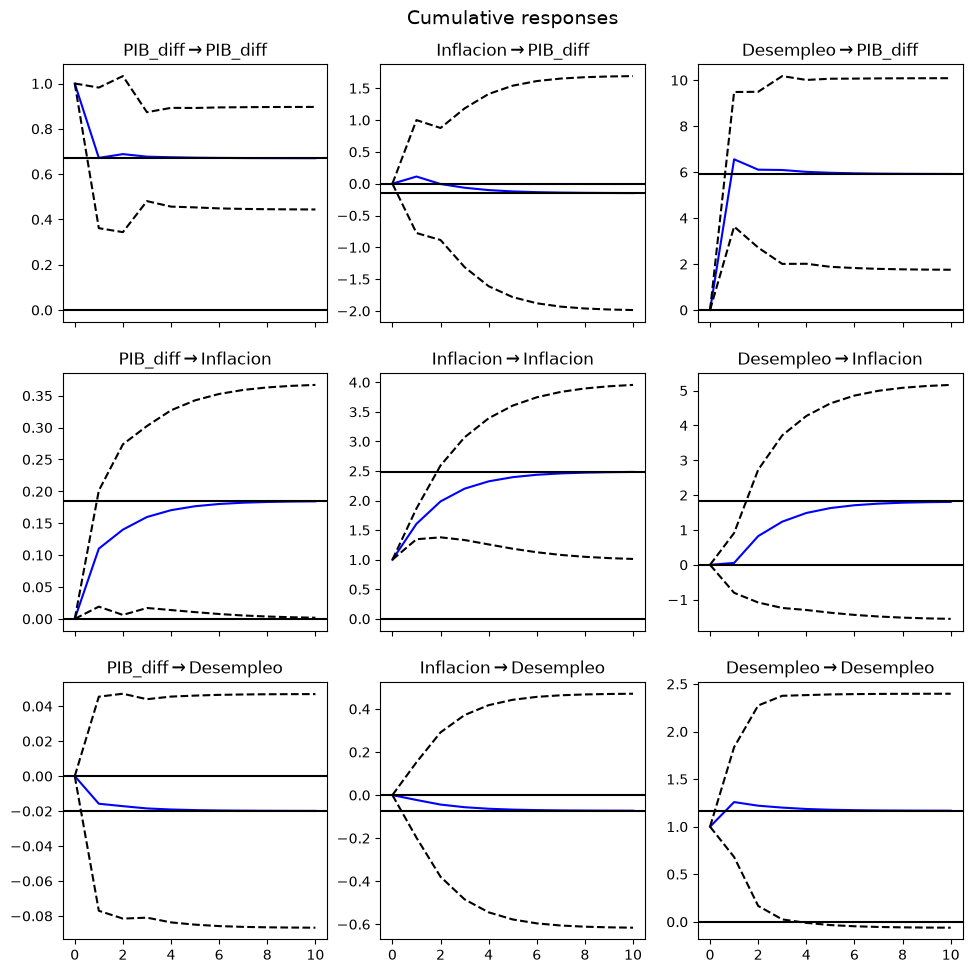

In [ ]:
irf.plot_cum_effects()
plt.show()

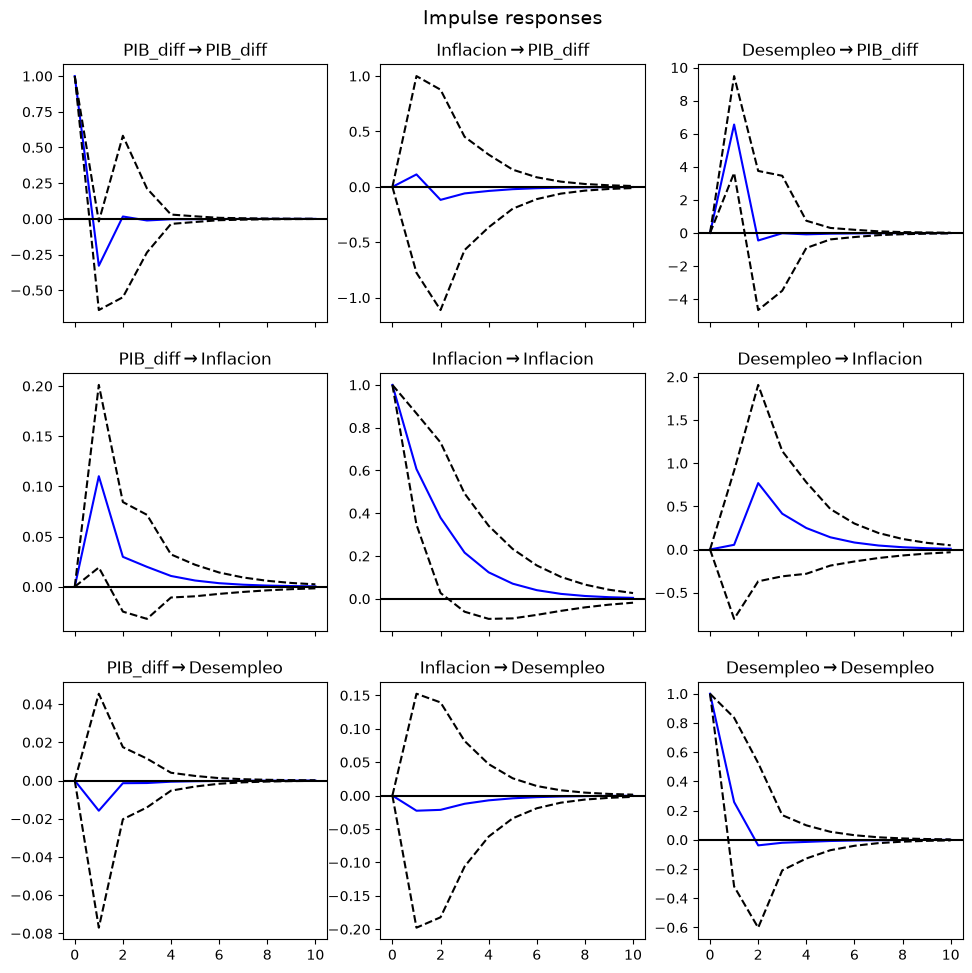

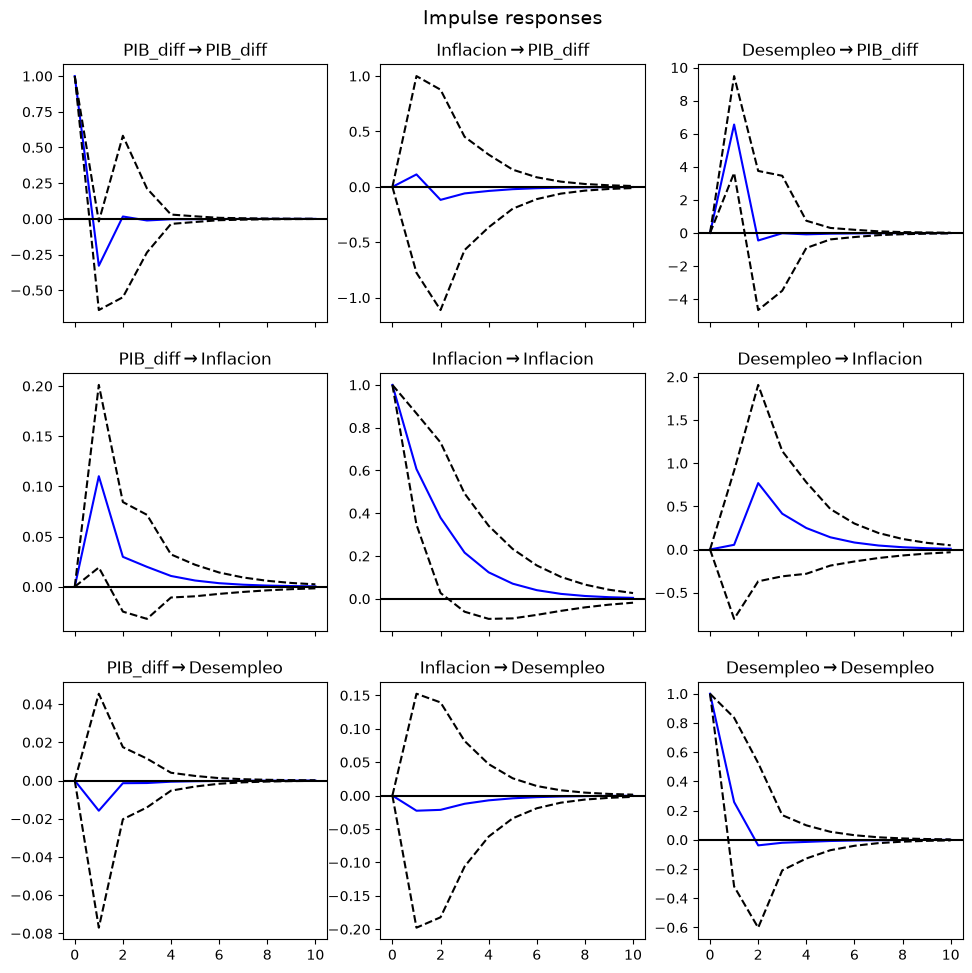

In [ ]:
irf.plot()

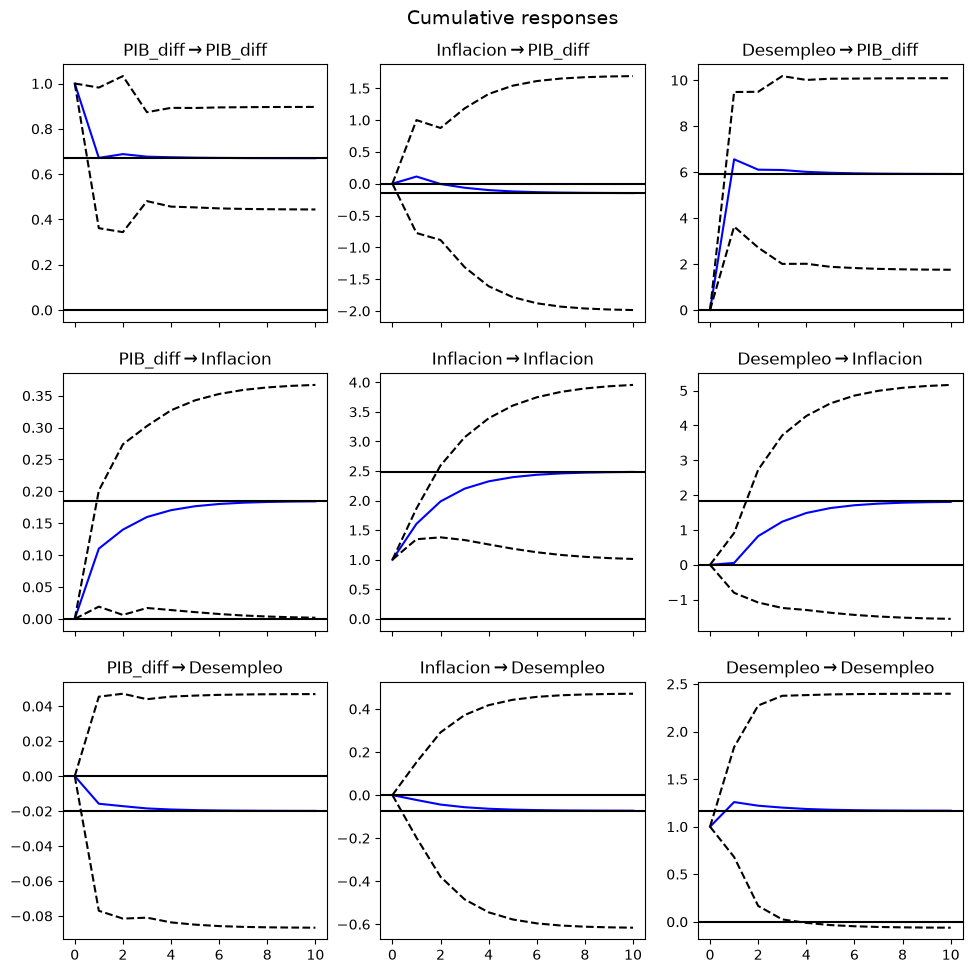

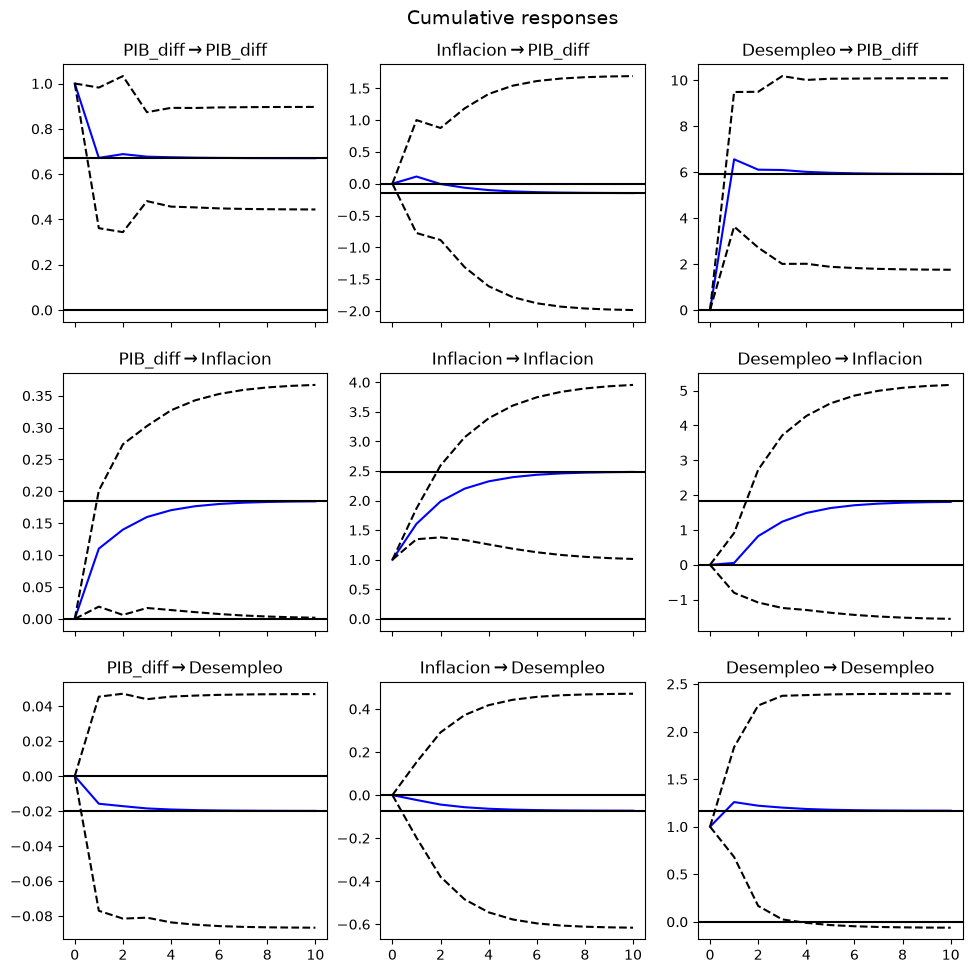

In [ ]:
irf.plot_cum_effects()

Descomposición de la varianza del error de pronóstico (FEVD)

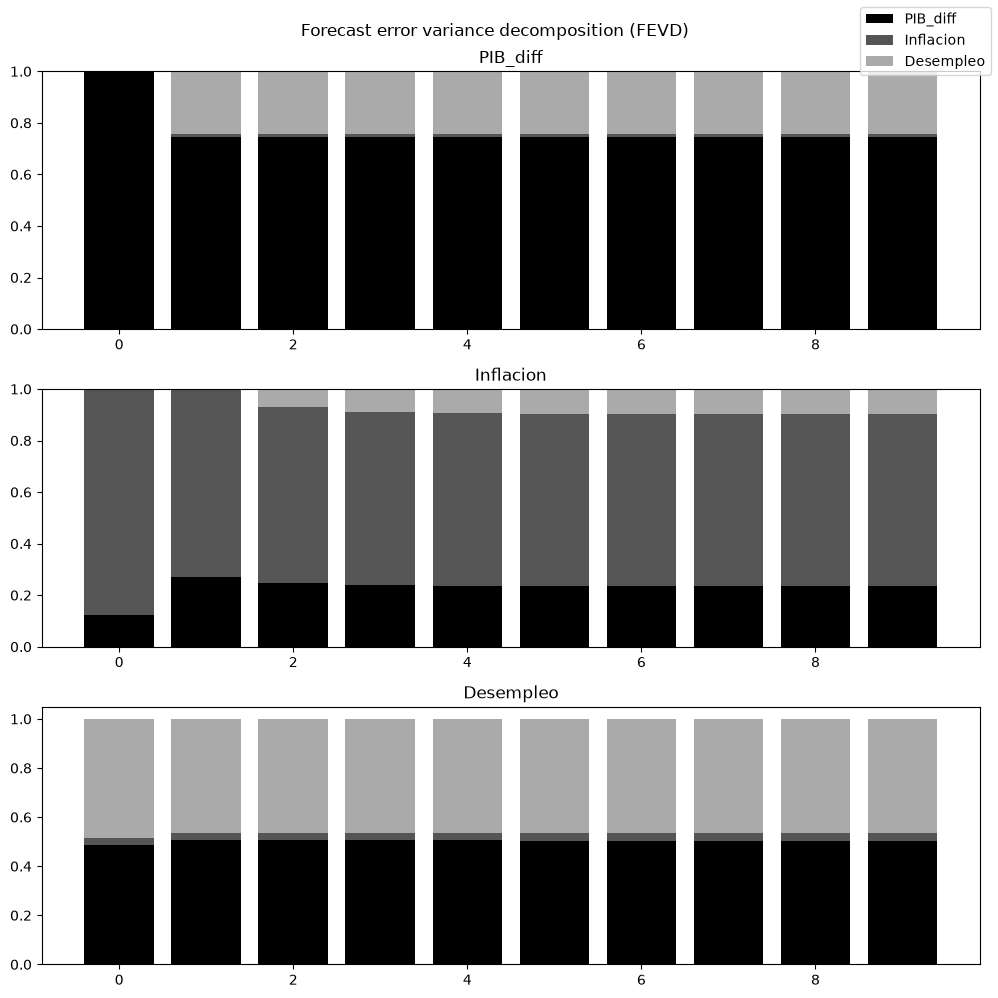

In [ ]:
import matplotlib.pyplot as plt

# Descomposición de la varianza a 10 períodos
fevd = modelo_var.fevd(10)

# Graficar
fevd.plot()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/Figura4_FEVD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Mostrar la descomposición para cada variable
print("FEVD para PIB_diff")
print(fevd.summary())

FEVD para PIB_diff
FEVD for PIB_diff
     PIB_diff  Inflacion  Desempleo
0    1.000000   0.000000   0.000000
1    0.746525   0.009521   0.243954
2    0.745931   0.009591   0.244478
3    0.745893   0.009664   0.244444
4    0.745854   0.009680   0.244466
5    0.745843   0.009686   0.244471
6    0.745840   0.009688   0.244473
7    0.745839   0.009688   0.244473
8    0.745838   0.009688   0.244473
9    0.745838   0.009688   0.244474

FEVD for Inflacion
     PIB_diff  Inflacion  Desempleo
0    0.123400   0.876600   0.000000
1    0.269662   0.729939   0.000399
2    0.246353   0.683013   0.070634
3    0.239371   0.672654   0.087975
4    0.237253   0.668783   0.093964
5    0.236569   0.667566   0.095864
6    0.236348   0.667168   0.096484
7    0.236276   0.667038   0.096686
8    0.236252   0.666996   0.096752
9    0.236245   0.666982   0.096773

FEVD for Desempleo
     PIB_diff  Inflacion  Desempleo
0    0.487976   0.026104   0.485920
1    0.505543   0.028300   0.466157
2    0.505003   0.02876

In [ ]:
# PIB
pd.DataFrame(
    fevd.decomp[:,0,:],
    columns=datos_var.columns
).to_csv("../outputs/tables/FEVD_PIB.csv", index=False)

# Inflación
pd.DataFrame(
    fevd.decomp[:,1,:],
    columns=datos_var.columns
).to_csv("../outputs/tables/FEVD_Inflacion.csv", index=False)

# Desempleo
pd.DataFrame(
    fevd.decomp[:,2,:],
    columns=datos_var.columns
).to_csv("../outputs/tables/FEVD_Desempleo.csv", index=False)